Dataset Shape: (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural          

/tmp/ipykernel_2458/1354313660.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_2458/1354313660.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try


===== Logistic Regression =====
Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


===== Random Forest =====
Accuracy: 0.7723577235772358
              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123


Confusion Matrix:
 [[18 25]
 [ 3 77]]


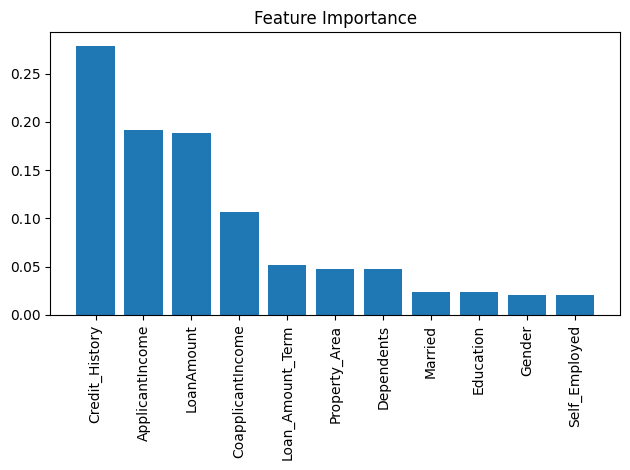

In [2]:
# =========================================
# Loan Default Prediction (Clean Version)
# =========================================

# 1. Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

# -----------------------------------------
# 2. Load Dataset
# -----------------------------------------
url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print(df.head())

# -----------------------------------------
# 3. Data Cleaning
# -----------------------------------------

# Drop unnecessary column
df.drop("Loan_ID", axis=1, inplace=True)

# Handle missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

# -----------------------------------------
# 4. Encode Categorical Variables
# -----------------------------------------

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# -----------------------------------------
# 5. Split Features & Target
# -----------------------------------------

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# -----------------------------------------
# 6. Train-Test Split
# -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------------------
# 7. Train Models
# -----------------------------------------

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# -----------------------------------------
# 8. Predictions
# -----------------------------------------

lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# -----------------------------------------
# 9. Evaluation
# -----------------------------------------

print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

# -----------------------------------------
# 10. Confusion Matrix (Random Forest)
# -----------------------------------------

cm = confusion_matrix(y_test, rf_preds)
print("\nConfusion Matrix:\n", cm)

# -----------------------------------------
# 11. Feature Importance (VERY IMPORTANT)
# -----------------------------------------

importances = rf_model.feature_importances_
features = X.columns

# Sort features
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()

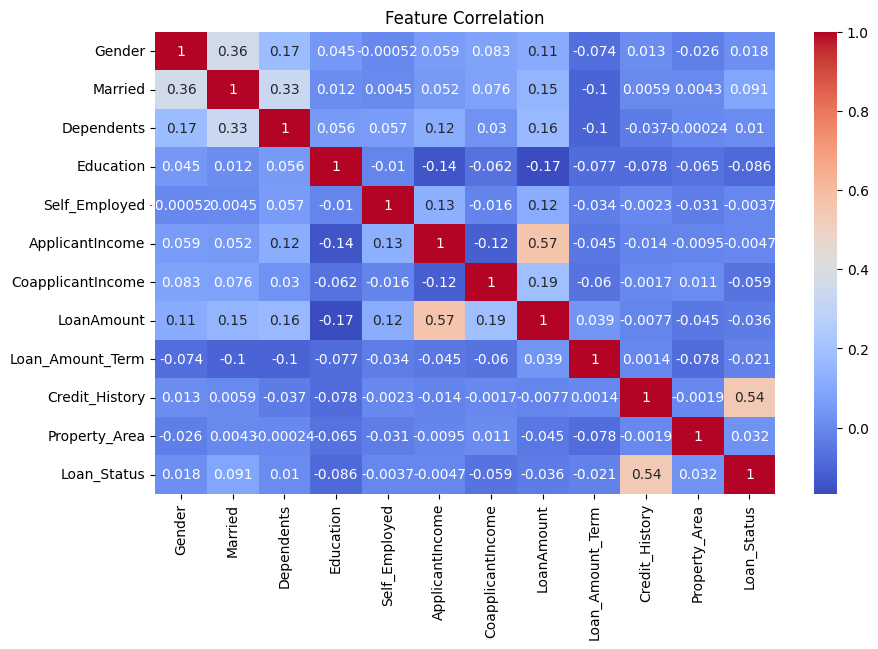

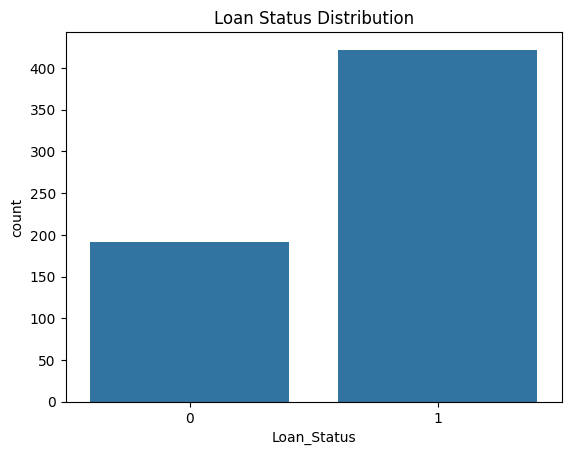

In [3]:
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# Loan Status distribution
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

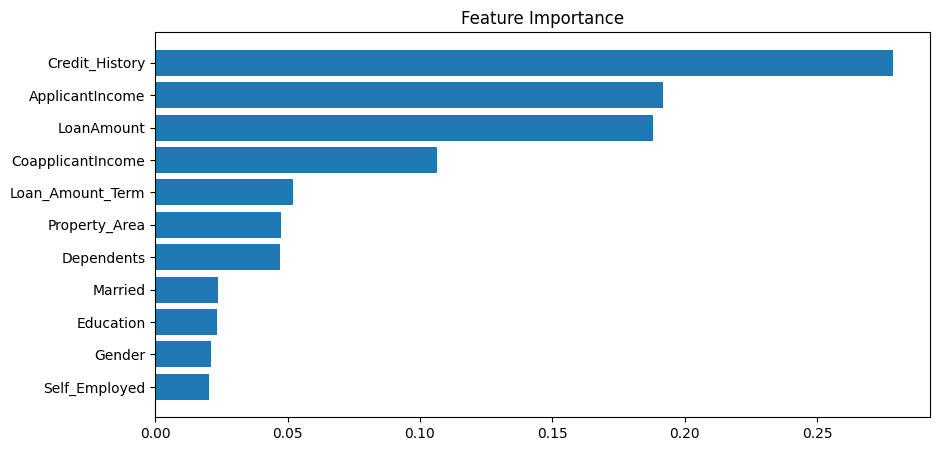

In [4]:
# Feature Importance (clean version)
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

 Conclusion

- Built a Loan Default Prediction system using Machine Learning
- Random Forest performed better than Logistic Regression
- Key factors affecting loan approval were identified using feature importance
- This model can help financial institutions reduce risk